# Caso Práctico: Neurona de McCulloch y Pitts

1. Implementación de la MPNeuron

In [14]:
! pip install pandas

  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.9 MB 1.7 MB/s eta 0:00:06
   - -------------------------------------- 0.3/9.9 MB 2.4 MB/s eta 0:00:04
   -- ------------------------------------- 0.7/9.9 MB 4.2 MB/s eta 0:00:03
   ----- ---------------------------------- 1.4/9.9 MB 6.6 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.9 MB 8.4 MB/s eta 0:00:01
   ----------- ---------------------------- 2.9/9.9 MB 9.8 MB/s eta 0:00:01
   --------------- ------------------------ 3.8/9.9 MB 11.0 MB/s eta 0:00:01
   ------------------ --------------------- 4.7/9.9 MB 12.0 MB/s eta 0:00:01
   ---------------------- ----------------- 5.6/9.9 MB 12.9 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.9 MB 13.9 MB/s eta 0:00:01
   ---------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
! pip install numpy

  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl (12.6 MB)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np

class MPNeuron:

    # Constructor con un atributo
    def __init__(self):
        self.threshold = None

    # Función hipótesis de esta neurona
    def model(self, x):
        # input: [0, 1, 1, 0] = [x1, x2, .., xn] -> el número de binarios (0, 1) es el número de características de entrada
        z = sum(x)
        return (z >= self.threshold)

    def predict(self, X):
        # inputs: [[1, 0, 0, 1], [0, 1, 0, 1]]
        Y = []
        for x in X:
            result = self.model(x)
            Y.append(result)
        return np.array(Y)
        

In [4]:
# Instanciamos la neurona
mp_neuron = MPNeuron()

In [5]:
# Establecemos un theshold
mp_neuron.threshold = 3

In [6]:
# Evaluamos diferentes casos
mp_neuron.predict([[0, 1, 1, 1], [1, 1, 0, 1], [1, 0, 0, 0]])

array([ True,  True, False])

# Aplicando la MPNeuron a un caso práctico real 

### 2.1. Conjunto de datos

Esta es una copia de los conjuntos de datos de UCI ML Breast Cancer Wisconsin (Diagnóstico). https://goo.gl/U2Uwz2

Las características de entrada se calculan a partir de una imagen digitalizada de un aspirado de aguja fina (FNA) de una masa mamaria. Describen las características de los núcleos celulares presentes en la imagen.

El plano de separación descrito anteriormente se obtuvo utilizando el método de árbol de múltiples superficies (MSM-T) [K. P. Bennett, "Construcción de un árbol de decisión mediante programación lineal". Proceedings of the 4th Midwest Artificial Intelligence and Cognitive Science Society, pp. 97-101, 1992], un método de clasificación que utiliza la programación lineal para construir un árbol de decisión. Los rasgos relevantes se seleccionaron mediante una búsqueda exhaustiva en el espacio de 1-4 rasgos y 1-3 planos de separación.

El programa lineal real utilizado para obtener el plano de separación en el espacio tridimensional es el que se describe en: [K. P. Bennett y O. L. Mangasarian: "Robust Linear Programming Discrimination of Two Linearly Inseparable Sets", Optimization Methods and Software 1, 1992, 23-34].

Esta base de datos también está disponible a través del servidor ftp UW CS:

ftp ftp.cs.wisc.edu cd math-prog/cpo-dataset/machine-learn/WDBC/

### Referencias

* W.N. Street, W.H. Wolberg and O.L. Mangasarian. Nuclear feature extraction for breast tumor diagnosis. IS&T/SPIE 1993 International Symposium on Electronic Imaging: Science and Technology, volume 1905, pages 861-870, San Jose, CA, 1993.
* O.L. Mangasarian, W.N. Street and W.H. Wolberg. Breast cancer diagnosis and prognosis via linear programming. Operations Research, 43(4), pages 570-577, July-August 1995.
* W.H. Wolberg, W.N. Street, and O.L. Mangasarian. Machine learning techniques to diagnose breast cancer from fine-needle aspirates. Cancer Letters 77 (1994) 163-171.

### 2.2. Lectura de conjunto de datos

In [7]:
! pip install scikit-learn

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB 1.4 MB/s eta 0:00:07
    --------------------------------------- 0.1/8.3 MB 1.4 MB/s eta 0:00:06
   - -------------------------------------- 0.4/8.3 MB 3.1 MB/s eta 0:00:03
   ---- ----------------------------------- 0.9/8.3 MB 5.1 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.3 MB 9.5 MB/s eta 0:00:01
   ------------ --------------------------- 2.6/8.3 MB 9.6 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.3 MB 13.4 MB/s eta 0:00:01
   ----------------------------- ---------- 6.1/8.3 MB 17.1 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 17.9 MB/s eta 0:00:01
   --------------------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer()

X = breast_cancer.data
Y = breast_cancer.target

In [9]:
type(breast_cancer)

sklearn.utils._bunch.Bunch

In [10]:
dir(breast_cancer)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [11]:
breast_cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [12]:
dir(breast_cancer)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

### 2.3. Visualización del conjunto de datos

In [15]:
import pandas as pd

df = pd.DataFrame(X, columns=breast_cancer.feature_names)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [16]:
type(df)

pandas.DataFrame

In [17]:
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

### 2.4. División del conjunto de datos

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, Y, stratify=Y)

print('Tamaño del conjunto de entrenamiento: ', len(X_train))
print('Tamaño del conjunto de prueba: ', len(X_test))

Tamaño del conjunto de entrenamiento:  426
Tamaño del conjunto de prueba:  143


### 2.4. Implementación de una MPNeuron más compleja

In [19]:
import numpy as np
from sklearn.metrics import accuracy_score

class MPNeuron:
    def __init__(self):
        self.threshold = None
    
    def model(self, x):
            z = sum(x)
            return (z >= self.threshold)
    
    def predict(self, X):
        Y = []
        for x in X:
            result = self.model(x)
            Y.append(result)
        return np.array(Y)
    # La función fit() busca el threshold que mejor se adapta a nuestro conjunto de datos
    def fit(self, X, Y):
        accuracy = {}
        # Seleccionamos un threshold entre el # de características de entrada
        for th in range(X.shape[1] + 1):
            self.threshold = th
            Y_pred = self.predict(X)
            accuracy[th] = accuracy_score(Y_pred, Y)
        # Seleccionamos el threshold que mejores resultados proporciona
        self.threshold = max(accuracy, key=accuracy.get)

Seguimos teniendo un problema debido a que en nuestro conjunto de datos las características de entrada reciben valores contínuos, sin embargo, nuestra MPNeuron solo procesa características de entrada con valor binario

In [21]:
! pip install matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 458.0 kB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     ----------------------------- --------- 92.2/121.0 kB 1.8 MB/s eta 0:00:01
     -------------------------------------- 121.0/121.0 kB 1.8 MB/s eta 0:00:00
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB 7.1 MB/s eta 0:00:02
   --- -----------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


[0, 0, 1, 1, 1, 0, 0]
Categories (2, int64): [0 < 1]


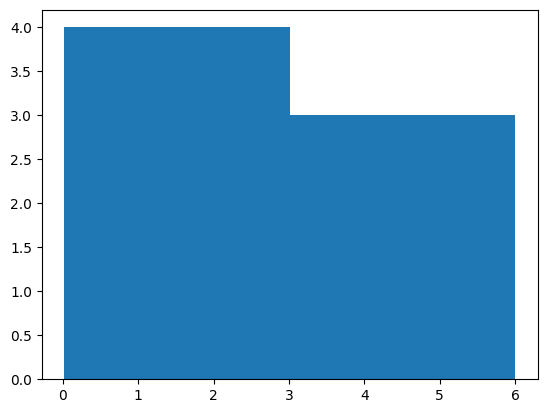

In [22]:
# Para transformar un valor a binario
import matplotlib.pyplot as plt

print(pd.cut([0.04, 2, 4, 5, 6, 0.02, 0.6], bins=2, labels=[0, 1]))

plt.hist([0.04, 0.3, 4, 5, 6, 0.02, 0.6], bins=2)
plt.show()

In [23]:
# Transformamos las características de entrada a un valor binario

X_train_bin = X_train.apply(pd.cut, bins=2, labels=[1, 0])
X_test_bin = X_test.apply(pd.cut, bins=2, labels=[1, 0])

X_train_bin

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
549,1,1,1,1,1,1,1,1,1,1,...,1,0,1,1,1,1,1,1,1,1
54,1,1,1,1,1,1,1,1,1,1,...,1,0,1,1,1,1,1,0,1,1
180,0,1,0,0,0,0,0,0,1,1,...,0,0,0,0,0,1,1,0,1,1
130,1,1,1,1,0,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
560,1,0,1,1,0,1,1,1,1,1,...,1,0,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
94,1,1,1,1,0,1,1,1,1,1,...,1,1,1,1,0,1,1,0,1,1
343,0,1,0,1,1,1,1,0,0,1,...,0,0,0,1,1,1,1,0,1,1
45,0,1,0,1,0,1,1,0,1,1,...,0,1,1,1,0,1,0,0,1,1


In [24]:
# Instanciamos el modelo MPNeuron
mp_neuron = MPNeuron()

# Encontramos el threshold óptimo
mp_neuron.fit(X_train_bin.to_numpy(), y_train)

In [25]:
# Threshold óptimo seleccionado

mp_neuron.threshold

28

In [26]:
# Realizamos predicciones para ejemplos nuevos que no se encuentran en el conjunto de datos de entrenamiento
Y_pred = mp_neuron.predict(X_test_bin.to_numpy())
Y_pred

array([ True, False,  True, False,  True, False, False, False, False,
        True,  True,  True,  True,  True,  True, False, False,  True,
       False,  True,  True,  True,  True, False, False,  True,  True,
        True, False,  True,  True,  True, False,  True, False,  True,
       False,  True, False, False,  True,  True, False,  True, False,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True, False,  True,  True, False,  True, False,  True,  True,
       False, False, False, False,  True,  True, False,  True, False,
        True,  True, False, False,  True, False,  True,  True, False,
       False,  True,  True,  True,  True, False, False, False,  True,
       False,  True,  True,  True, False,  True,  True, False,  True,
        True, False, False,  True, False, False, False,  True, False,
        True,  True,  True, False,  True,  True,  True, False,  True,
        True, False, False, False, False,  True,  True,  True, False,
       False,  True,

In [27]:
# Calculamos la exactitud de nuestra predicción

accuracy_score(y_test, Y_pred)

0.8671328671328671

In [28]:
# Calculamos la matriz de confusión
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, Y_pred)

array([[47,  6],
       [13, 77]])